# Mini Project 2 Notebook

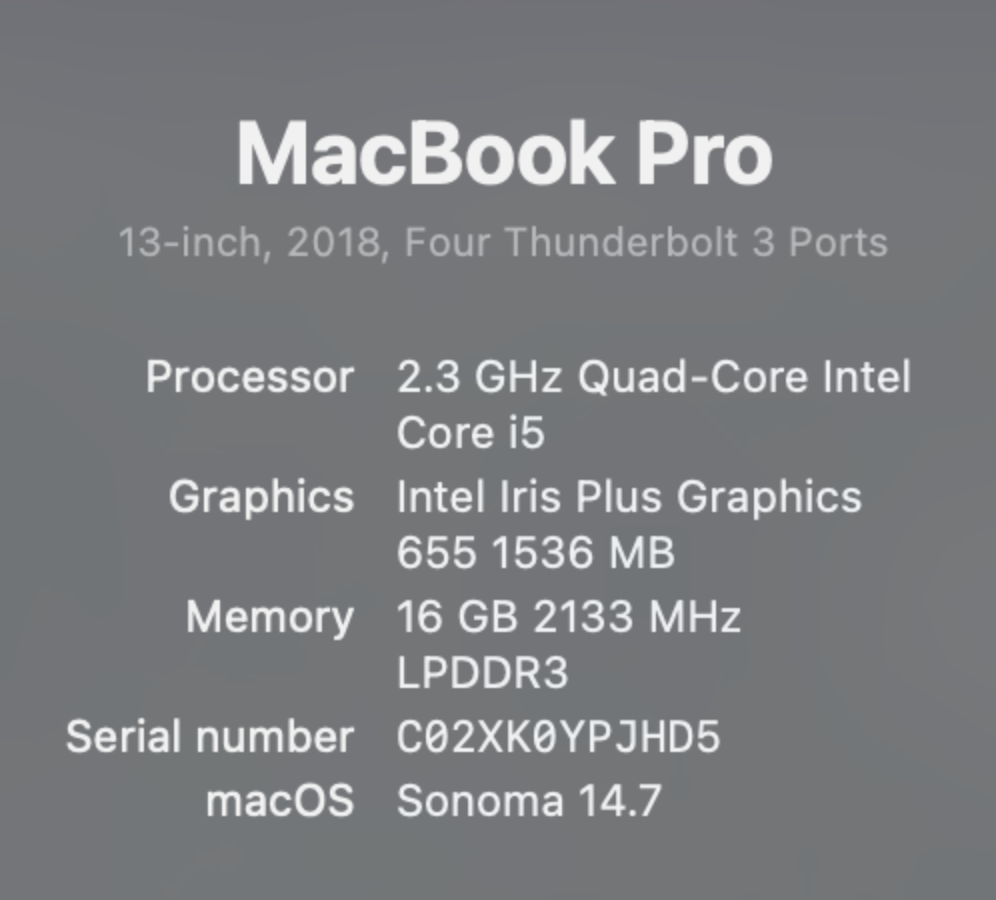

In [1]:
import numpy
import sys 
print(sys.version)
print('Numpy version:', numpy.__version__)

3.14.3 | packaged by conda-forge | (main, Feb  5 2026, 05:57:55) [Clang 20.1.8 ]
Numpy version: 2.3.5


### Measurement methodology
- 3 trials (4 if jit is involved as a warmup), take the median and report standard deviation.
- All multiprocessing runs are warmed up before timings

In [2]:
import pandas as pd

## Multiprocessing vs serial speedup

In [3]:
from main import w4_testing
_, median_serial, var_serial, medians = w4_testing(win_size=1024)

Benchmarking serial approach
Median execution time over 4 runs: 0.602909 seconds
Benchmarking parallel approach
Running on 1 cores
Median execution time over 3 runs for 1: 0.268512 seconds
Running on 2 cores
Median execution time over 3 runs for 2: 0.124212 seconds
Running on 3 cores
Median execution time over 3 runs for 3: 0.078487 seconds
Running on 4 cores
Median execution time over 3 runs for 4: 0.066233 seconds
Running on 5 cores
Median execution time over 3 runs for 5: 0.052239 seconds
Running on 6 cores
Median execution time over 3 runs for 6: 0.072315 seconds
Running on 7 cores
Median execution time over 3 runs for 7: 0.046788 seconds
Running on 8 cores
Median execution time over 3 runs for 8: 0.036877 seconds


In [4]:
import pandas as pd

df = pd.DataFrame({
    'NoCore': range(1, 9),
    'medians': medians,
})

# Calculate the speedup column
df['speedup'] = median_serial / df['medians']

df

,NoCore,medians,speedup
0,1,0.268512,2.245375
1,2,0.124212,4.853880
2,3,0.078487,7.681671
3,4,0.066233,9.102899
4,5,0.052239,11.541287
5,6,0.072315,8.337290
6,7,0.046788,12.886055
7,8,0.036877,16.349346


Using the serial approach as a baseline, it can be seen that a speedup of 6.66 has been achieved using all 8 physical cores

## Multiprocessing LIF
Knowing that the optimal number of processers is 8 we use this for testing chunk sizes. 
Chunk sizes are calculated as number of processes multiplied by a value

In [5]:
from main import w5_chunk_testing
medians, LIFs, _ = w5_chunk_testing(win_size=1024, chunk_range=range(1,17))

Median execution time over 4 runs: 0.230287 seconds
Execution time for 8 processes and 8 chunks: 0.031602 seconds and 0.097826 LIF
Execution time for 8 processes and 16 chunks: 0.017219 seconds and -0.401826 LIF
Execution time for 8 processes and 24 chunks: 0.011178 seconds and -0.611684 LIF
Execution time for 8 processes and 32 chunks: 0.008705 seconds and -0.697610 LIF
Execution time for 8 processes and 40 chunks: 0.024141 seconds and -0.161368 LIF
Execution time for 8 processes and 48 chunks: 0.008788 seconds and -0.694710 LIF
Execution time for 8 processes and 56 chunks: 0.009291 seconds and -0.677249 LIF
Execution time for 8 processes and 64 chunks: 0.008433 seconds and -0.707044 LIF
Execution time for 8 processes and 72 chunks: 0.008371 seconds and -0.709212 LIF
Execution time for 8 processes and 80 chunks: 0.008925 seconds and -0.689953 LIF
Execution time for 8 processes and 88 chunks: 0.009212 seconds and -0.679996 LIF
Execution time for 8 processes and 96 chunks: 0.009482 seco

In [6]:
df = pd.DataFrame([list(medians.keys()), list(medians.values()), list(LIFs.values())])
df_transposed = df.transpose()
df_transposed.columns = ['No. Chunks','time', 'LIF']  # Rename the columns
df_transposed

df_transposed['vs x1'] = df_transposed['No. Chunks'] / 8 # Divide by 8
df_transposed['speedup'] = median_serial / df_transposed['time']   # Replace t_serial with your actual serial time
df_transposed

,No. Chunks,time,LIF,vs x1,speedup
0,8.0,0.031602,0.097826,1.0,19.078290
1,16.0,0.017219,-0.401826,2.0,35.014256
2,24.0,0.011178,-0.611684,3.0,53.937128
3,32.0,0.008705,-0.697610,4.0,69.263555
4,40.0,0.024141,-0.161368,5.0,24.974766
5,48.0,0.008788,-0.694710,6.0,68.605727
6,56.0,0.009291,-0.677249,7.0,64.894098
7,64.0,0.008433,-0.707044,8.0,71.494008
8,72.0,0.008371,-0.709212,9.0,72.027247
9,80.0,0.008925,-0.689953,10.0,67.553047


<Axes: title={'center': 'No Chunks vs speedup'}, xlabel='No. Chunks'>

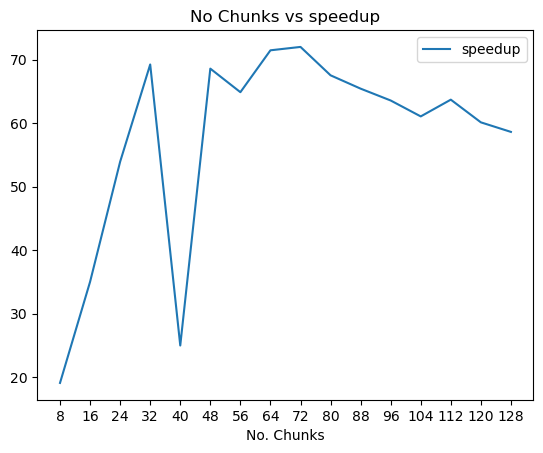

In [7]:
df_transposed.plot(x='No. Chunks', y='speedup', title='No Chunks vs speedup', xticks=range(1*8, 17*8, 8))

In [8]:
from main import benchmark_all
d = benchmark_all(n_runs=3)

Week 1: Naive python implementation
Execution took: 7.016362 seconds
Execution took: 6.879858 seconds
Execution took: 7.302734 seconds
Median execution time over 3 runs: 7.016548 seconds
Week 2: numpy vectorization
Execution took: 1.269700 seconds
Execution took: 1.343490 seconds
Execution took: 1.249091 seconds
Median execution time over 3 runs: 1.295110 seconds
Week 3: Naive numba
Execution took: 0.760632 seconds
Execution took: 0.625818 seconds
Execution took: 0.623094 seconds
Median execution time over 3 runs: 0.626459 seconds
Week 3: optimized numba
Execution took: 0.229994 seconds
Execution took: 0.082780 seconds
Execution took: 0.080887 seconds
Median execution time over 3 runs: 0.092900 seconds
Week 4: parallel computing
w4 median_w4 0.03320992100634612, 
w4 variance 1.6235747939695928e-06
Week 5: parallel computing with pools
Median execution time over 4 runs: 0.228243 seconds
Median time for w5: 0.01199820201145485, 
w5 variance 0.21478775364035918
Week 6: Dask local
Dashboar

In [9]:
df = pd.DataFrame([d.get('w1_median'), d.get('w2_median'), d.get('w3_median'), d.get('w4_median'), d.get('w5_median')])
df.columns = ['Timings']
df['Weeks'] = ['Naive', 'Numpy', 'numba','Parallel', 'Parallel Pooling']
naive = df['Timings'][0]
df['Speedup'] = naive / df['Timings']
df['LIF'] = [numpy.nan, numpy.nan, numpy.nan, numpy.nan, d.get('w5_LIF')]
df = df[['Weeks', 'Timings', 'Speedup', 'LIF']]
df

,Weeks,Timings,Speedup,LIF
0,Naive,7.016548,1.000000,NaN
1,Numpy,1.295110,5.417724,NaN
2,numba,0.092900,75.527790,NaN
3,Parallel,0.033210,211.278685,NaN
4,Parallel Pooling,0.011998,584.799993,-0.579459


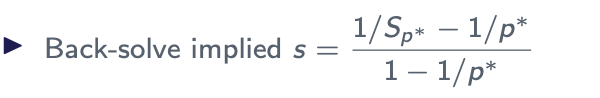

In [10]:
s4 = (1/df['Speedup'][3] - 1/8) / (1-1/8)
s5 = (1/df['Speedup'][4] - 1/8) / (1-1/8)
print(f'Parallel load balance: {s4}, parallel with pool load balance {s5}')

Parallel load balance: -0.13744790272991528, parallel with pool load balance -0.1409028727532621


 - Through processor sweeping it has been found that 8 processors is always optimal. Through chunk sweeping it has been found that numbers around 48 or 6*processors is around optimal, although this can range between 4-8 for differing runs
 - parallelisation has been very worth it, giving over 600x increase in speedup vs naive on parallel with pooling and 200+ with a standard parallel approach

## Testing with chunksize with dask
Initially just test chunk sizes 8 - 1024 whilst doubling

In [11]:
from main import w6_testing
import pandas as pd
chunks = [8, 16, 32, 64, 128, 256, 512, 1024]
chunks, t_serial = w6_testing(win_size=4096, n_runs=5, testing_chunks=chunks)

Dashboard: http://127.0.0.1:8787/status
Execution for serial took: 3.716923 seconds
median time for dask worker: 0.6045884079940151
median time for dask worker: 0.3531834649911616
median time for dask worker: 0.24156793300062418
median time for dask worker: 0.2465797970071435
median time for dask worker: 0.3251587260165252
median time for dask worker: 0.5778774319915101
median time for dask worker: 1.0752694669936318
median time for dask worker: 2.2890975539921783


In [12]:
df = pd.DataFrame(chunks)
df_transposed = df.transpose()
df_transposed = df_transposed.reset_index()
df_transposed.columns = ['No. Chunks','time', 'LIF']  # Rename the columns
df_transposed

df_transposed['vs x1'] = 8 / df_transposed['No. Chunks']  # Divide by 8
df_transposed['speedup'] = t_serial / df_transposed['time']   
df_transposed

,No. Chunks,time,LIF,vs x1,speedup
0,8,0.604588,0.301267,1.000000,6.147856
1,16,0.353183,-0.239837,0.500000,10.524056
2,32,0.241568,-0.480069,0.250000,15.386656
3,64,0.246580,-0.469282,0.125000,15.073914
4,128,0.325159,-0.300155,0.062500,11.431102
5,256,0.577877,0.243776,0.031250,6.432026
6,512,1.075269,1.314322,0.015625,3.456736
7,1024,2.289098,3.926866,0.007812,1.623750


In [13]:
import numpy as np
chunks = np.linspace(16, 64, 7, dtype=int)
chunks, t_serial = w6_testing(win_size=4096, n_runs=5, testing_chunks=list(chunks))
df = pd.DataFrame(chunks)
df_transposed = df.transpose()
df_transposed = df_transposed.reset_index()
df_transposed.columns = ['No. Chunks','time', 'LIF']  # Rename the columns
df_transposed

df_transposed['vs x1'] = df_transposed['No. Chunks'] / 8  # Divide by 8
df_transposed['speedup'] = t_serial / df_transposed['time']   # Replace t_serial with your actual serial time
df_transposed

Dashboard: http://127.0.0.1:8787/status
Execution for serial took: 3.865883 seconds
median time for dask worker: 0.35380474699195474
median time for dask worker: 0.27414421702269465
median time for dask worker: 0.23475754700484686
median time for dask worker: 0.24908923197654076
median time for dask worker: 0.2604594280128367
median time for dask worker: 0.22855740200611763
median time for dask worker: 0.3063702369981911


,No. Chunks,time,LIF,vs x1,speedup
0,16,0.353805,-0.267842,2.0,10.926599
1,24,0.274144,-0.432690,3.0,14.101639
2,32,0.234758,-0.514196,4.0,16.467555
3,40,0.249089,-0.484538,5.0,15.520072
4,48,0.260459,-0.461009,6.0,14.842553
5,56,0.228557,-0.527027,7.0,16.914275
6,64,0.306370,-0.366002,8.0,12.618337


<Axes: xlabel='No. Chunks'>

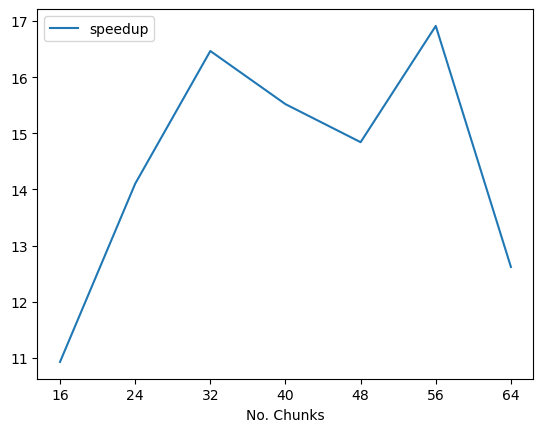

In [14]:
df_transposed.plot(x='No. Chunks', y='speedup', xticks=np.linspace(16, 64, 7, dtype=int))

The optimal speedup is  from 6-8x processors or 48-64, this often differs run to run, but the most optimal has been 48 overall

In [15]:
df = pd.DataFrame([d.get('w1_median'), d.get('w2_median'), d.get('w3_median'), d.get('w4_median'), d.get('w5_median'), d.get('w6_median')])
df.columns = ['Timings']
df['Weeks'] = ['Naive', 'Numpy', 'numba','Parallel', 'Parallel Pooling', 'Dask local']
naive = df['Timings'][0]
df['Speedup'] = naive / df['Timings']
df['LIF'] = [numpy.nan, numpy.nan, numpy.nan, numpy.nan, d.get('w5_LIF'), d.get('w6_LIF')]
df = df[['Weeks', 'Timings', 'Speedup', 'LIF']]
df

,Weeks,Timings,Speedup,LIF
0,Naive,7.016548,1.000000,NaN
1,Numpy,1.295110,5.417724,NaN
2,numba,0.092900,75.527790,NaN
3,Parallel,0.033210,211.278685,NaN
4,Parallel Pooling,0.011998,584.799993,-0.579459
5,Dask local,0.090943,77.153445,2.141600


Dask local is worse in this case as we use a 1024 grid, it is shown to work better on larger grids

In [17]:
from main import bennchmark_parallel
f = bennchmark_parallel(size=4096)
df = pd.DataFrame([f.get('w4_median'), f.get('w5_median'), f.get('w6_median')])
df.columns = ['Timings']
df['Weeks'] = ['Parallel', 'Parallel Pooling', 'Dask local']
naive = t_serial # Benchmark from serial time
df['Speedup'] = naive / df['Timings']
df['LIF'] = [numpy.nan, d.get('w5_LIF'), d.get('w6_LIF')]
df = df[['Weeks', 'Timings', 'Speedup', 'LIF']]
df


Week 4: parallel computing
w4 median_w4 0.5307652569899801, 
w4 variance 4.064715747731534e-05
Week 5: parallel computing with pools
Median execution time over 4 runs: 3.678028 seconds
Median time for w5: 0.26840064200223424, 
w5 variance 0.20014127281438668
Week 6: Dask local
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.22861844502040185
Execution for serial took: 3.814003 seconds
Median time for w6: 0.22861844502040185, 
w6 variance 0.00011669589565333773


,Weeks,Timings,Speedup,LIF
0,Parallel,0.530765,7.283602,NaN
1,Parallel Pooling,0.268401,14.403404,-0.579459
2,Dask local,0.228618,16.909759,2.141600


We can see that there is an increase in speedup when using a larger mandelbrot size